# SuperStore Sales Forcasting Project

## import all libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('SuperStore Sales Dataset.csv')

### Dataset Understanding

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [5]:
df.shape

(9800, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Data Cleaning

In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

There are 11 missing values in Postal Code column.

In [9]:
df.duplicated().sum()

np.int64(0)

Find all the missing Postal Code rows.

In [10]:
df[df['Postal Code'].isnull()][
    ['City', 'State', 'Region', 'Postal Code']
]

,City,State,Region,Postal Code
2234,Burlington,Vermont,East,NaN
5274,Burlington,Vermont,East,NaN
8798,Burlington,Vermont,East,NaN
9146,Burlington,Vermont,East,NaN
9147,Burlington,Vermont,East,NaN
9148,Burlington,Vermont,East,NaN
9386,Burlington,Vermont,East,NaN
9387,Burlington,Vermont,East,NaN
9388,Burlington,Vermont,East,NaN
9389,Burlington,Vermont,East,NaN


There were 11 missing values in the Postal Code column, all belonging to Burlington, Vermont. Since the missing postal code could not be obtained from other records in the dataset, the missing values were filled with the corresponding Burlington, Vermont postal code (5401). After filling, no missing values remained in the Postal Code column.

In [11]:
df.loc[(df['City'] == 'Burlington') & (df['State'] == 'Vermont') & (df['Postal Code'].isnull()), 'Postal Code'] = 54001

In [12]:
df.sample(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
3830,3831,CA-2018-141733,07/05/2018,11/05/2018,Standard Class,RW-19540,Rick Wilson,Corporate,United States,Detroit,Michigan,48234.0,Central,OFF-AP-10001563,Office Supplies,Appliances,Belkin Premiere Surge Master II 8-outlet surge...,87.444
2334,2335,CA-2015-140886,30/09/2015,04/10/2015,Standard Class,KW-16570,Kelly Williams,Consumer,United States,Clarksville,Tennessee,37042.0,South,OFF-AP-10000696,Office Supplies,Appliances,Holmes Odor Grabber,69.216
7161,7162,CA-2015-138709,04/07/2015,09/07/2015,Standard Class,MS-17770,Maxwell Schwartz,Consumer,United States,Richmond,Virginia,23223.0,South,OFF-PA-10004734,Office Supplies,Paper,Southworth Structures Collection,21.840
6800,6801,CA-2017-109827,25/12/2017,01/01/2018,Standard Class,LW-16825,Laurel Workman,Corporate,United States,Phoenix,Arizona,85023.0,West,TEC-MA-10003356,Technology,Machines,Panasonic KX MC6040 Color Laser Multifunction ...,269.970
4855,4856,CA-2015-113320,12/12/2015,15/12/2015,Second Class,LH-17155,Logan Haushalter,Consumer,United States,Oakland,California,94601.0,West,FUR-FU-10001706,Furniture,Furnishings,Longer-Life Soft White Bulbs,9.240
4728,4729,CA-2015-123323,07/11/2015,12/11/2015,Standard Class,LH-16900,Lena Hernandez,Consumer,United States,San Francisco,California,94110.0,West,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,123.144
5580,5581,CA-2018-137498,09/09/2018,14/09/2018,Second Class,LC-17050,Liz Carlisle,Consumer,United States,Los Angeles,California,90004.0,West,OFF-PA-10000143,Office Supplies,Paper,Astroparche Fine Business Paper,47.520
6180,6181,CA-2016-158421,21/09/2016,26/09/2016,Standard Class,GB-14575,Giulietta Baptist,Consumer,United States,Columbia,South Carolina,29203.0,South,TEC-PH-10000369,Technology,Phones,HTC One Mini,629.950
4038,4039,CA-2015-110786,29/12/2015,02/01/2016,Standard Class,AJ-10795,Anthony Johnson,Corporate,United States,San Francisco,California,94110.0,West,OFF-PA-10000528,Office Supplies,Paper,Xerox 1981,21.120
8085,8086,CA-2017-105753,20/10/2017,26/10/2017,Standard Class,LC-16960,Lindsay Castell,Home Office,United States,Arlington,Virginia,22204.0,South,FUR-FU-10000246,Furniture,Furnishings,Aluminum Document Frame,61.100


In [13]:
df['Postal Code'].isnull().sum()

np.int64(0)

We need Order Date and Ship Date as a proper datetime before doing monthly/yearly forecasting.

In [14]:
df[['Order Date','Ship Date']].dtypes

Order Date    str
Ship Date     str
dtype: object

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst = True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst = True)

In [16]:
df[['Order Date','Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

Find Unique Values in each columns of (str Datatypes)

In [17]:
print("Ship Mode:")
print(df['Ship Mode'].unique())

print("\nSegment:")
print(df['Segment'].unique())

print("\nCity")
print(df['City'].unique())

print("\nState")
print(df['State'].unique())

print("\nRegion")
print(df['Region'].unique())

print("\nCategory")
print(df['Category'].unique())

print("\nSub-Category")
print(df['Sub-Category'].unique())

Ship Mode:
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

Segment:
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

City
<StringArray>
[        'Henderson',       'Los Angeles',   'Fort Lauderdale',
           'Concord',           'Seattle',        'Fort Worth',
           'Madison',       'West Jordan',     'San Francisco',
           'Fremont',
 ...
        'Pine Bluff',          'Aberdeen',        'Hagerstown',
       'East Orange', 'Arlington Heights',            'Oswego',
       'Coon Rapids',      'San Clemente',   'San Luis Obispo',
        'Springdale']
Length: 529, dtype: str

State
<StringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',           'Washington',                'Texas',
            'Wisconsin',                 'Utah',             'Nebraska',
         'Pennsylvania',             'Illinois',            'Minnesota',
             '

### Data Preprocessing

Extract Year and Months from Order Date

In [18]:
print("Maximum Date:", df['Order Date'].max())
print("Minimum Date:", df['Order Date'].min())

Maximum Date: 2018-12-30 00:00:00
Minimum Date: 2015-01-03 00:00:00


In [19]:
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Month_Name'] = df['Order Date'].dt.month_name()
df['Order_Day'] = df['Order Date'].dt.day
df['Year_Month'] = df['Order Date'].dt.to_period('M')

In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Order_Year,Order_Month,Order_Month_Name,Order_Day,Year_Month
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,8,2017-11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,8,2017-11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,12,2017-06
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,11,2016-10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,11,2016-10


## Data Analysis

### Monthly Sales Analysis

In [21]:
Monthly_Sales = df.groupby('Year_Month')['Sales'].sum().reset_index()
Monthly_Sales

,Year_Month,Sales
0,2015-01,14205.7070
1,2015-02,4519.8920
2,2015-03,55205.7970
3,2015-04,27906.8550
4,2015-05,23644.3030
5,2015-06,34322.9356
6,2015-07,33781.5430
7,2015-08,27117.5365
8,2015-09,81623.5268
9,2015-10,31453.3930


In [22]:
Monthly_Sales['Year_Month'] = Monthly_Sales['Year_Month'].dt.to_timestamp()
Monthly_Sales.head()

,Year_Month,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [23]:
Highest_Month = Monthly_Sales.loc[Monthly_Sales['Sales'].idxmax()]
Lowest_Month = Monthly_Sales.loc[Monthly_Sales['Sales'].idxmin()]

print("Highest Sales Month:")
print(Highest_Month)

print("\nLowest Sales Month:")
print(Lowest_Month)

Highest Sales Month:
Year_Month    2018-11-01 00:00:00
Sales                  117938.155
Name: 46, dtype: object

Lowest Sales Month:
Year_Month    2015-02-01 00:00:00
Sales                    4519.892
Name: 1, dtype: object


### Yearly Sales Analysis

In [24]:
Yearly_Sales = df.groupby('Order_Year')['Sales'].sum().reset_index()
Yearly_Sales

,Order_Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


In [25]:
Highest_Year = Yearly_Sales.loc[Yearly_Sales['Sales'].idxmax()]
Lowest_Year = Yearly_Sales.loc[Yearly_Sales['Sales'].idxmin()]

print("Highest Sales Year:")
print(Highest_Year)

print("\nLowest Sales Year:")
print(Lowest_Year)

Highest Sales Year:
Order_Year      2018.0000
Sales         722052.0192
Name: 3, dtype: float64

Lowest Sales Year:
Order_Year      2016.0000
Sales         459436.0054
Name: 1, dtype: float64


## Prepare Data for Forecasting

### Create Monthly Forecasting Dataset

In [26]:
#Copy for forecasting
Forecast_df = Monthly_Sales.copy()

#numeric time index
Forecast_df['Time_Index'] = range(len(Forecast_df))

# Display the forecasting dataset
Forecast_df.head()

,Year_Month,Sales,Time_Index
0,2015-01-01,14205.707,0
1,2015-02-01,4519.892,1
2,2015-03-01,55205.797,2
3,2015-04-01,27906.855,3
4,2015-05-01,23644.303,4


In [27]:
Forecast_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Year_Month  48 non-null     datetime64[us]
 1   Sales       48 non-null     float64       
 2   Time_Index  48 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.3 KB


### Split Data into Training and Testing Sets

In [28]:
split_index = int(len(Forecast_df) * 0.8)

train = Forecast_df.iloc[:split_index].copy()
test = Forecast_df.iloc[split_index:].copy()

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("\nTraining period:")
print(train['Year_Month'].min(), "to", train['Year_Month'].max())

print("\nTesting period:")
print(test['Year_Month'].min(), "to", test['Year_Month'].max())

Training data: (38, 3)
Testing data: (10, 3)

Training period:
2015-01-01 00:00:00 to 2018-02-01 00:00:00

Testing period:
2018-03-01 00:00:00 to 2018-12-01 00:00:00


### Build the Linear Regression Model

In [29]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from sklearn.linear_model import LinearRegression

# Input and target
X_train = train[['Time_Index']]
y_train = train['Sales']

X_test = test[['Time_Index']]
y_test = test['Sales']

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict test data
test['Predicted_Sales'] = model.predict(X_test)

test[['Year_Month', 'Sales', 'Predicted_Sales']]

,Year_Month,Sales,Predicted_Sales
38,2018-03-01,58863.4128,55563.601236
39,2018-04-01,35541.9101,56249.882764
40,2018-05-01,43825.9822,56936.164291
41,2018-06-01,48190.7277,57622.445819
42,2018-07-01,44825.1040,58308.727347
43,2018-08-01,62837.8480,58995.008875
44,2018-09-01,86152.8880,59681.290402
45,2018-10-01,77448.1312,60367.571930
46,2018-11-01,117938.1550,61053.853458
47,2018-12-01,83030.3888,61740.134986


### Evaluate the Forecasting Model

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, test['Predicted_Sales'])

mse = mean_squared_error(y_test, test['Predicted_Sales'])

rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 18560.28591345771
Mean Squared Error: 557870823.4211354
Root Mean Squared Error: 23619.289223453263


In [35]:
test[['Year_Month', 'Sales', 'Predicted_Sales']]

,Year_Month,Sales,Predicted_Sales
38,2018-03-01,58863.4128,55563.601236
39,2018-04-01,35541.9101,56249.882764
40,2018-05-01,43825.9822,56936.164291
41,2018-06-01,48190.7277,57622.445819
42,2018-07-01,44825.1040,58308.727347
43,2018-08-01,62837.8480,58995.008875
44,2018-09-01,86152.8880,59681.290402
45,2018-10-01,77448.1312,60367.571930
46,2018-11-01,117938.1550,61053.853458
47,2018-12-01,83030.3888,61740.134986


### Future Sales Forcasting

In [40]:
future_months = 6
last_time_index = Forecast_df['Time_Index'].max()

future_df = pd.DataFrame({ 
        'Time_Index': range(
        last_time_index + 1,
        last_time_index + 1 + future_months
    )
})

future_df['Year_Month'] = pd.date_range(
    start=Forecast_df['Year_Month'].max() + pd.DateOffset(months=1),
    periods=future_months,
    freq='MS'
)

future_df

,Time_Index,Year_Month
0,48,2019-01-01
1,49,2019-02-01
2,50,2019-03-01
3,51,2019-04-01
4,52,2019-05-01
5,53,2019-06-01


In [41]:
future_df['Predicted_Sales'] = model.predict(future_df[['Time_Index']])
future_df

,Time_Index,Year_Month,Predicted_Sales
0,48,2019-01-01,62426.416513
1,49,2019-02-01,63112.698041
2,50,2019-03-01,63798.979569
3,51,2019-04-01,64485.261097
4,52,2019-05-01,65171.542624
5,53,2019-06-01,65857.824152


## Forecast Results Analysis

The future sales forecast was analyzed to identify the highest and lowest predicted sales months. The average forecasted sales for the upcoming six months was also calculated. The first and last forecasted values were compared to determine the overall direction of the predicted sales trend.


In [44]:
highest_forecast_sales = future_df.loc[future_df['Predicted_Sales'].idxmax()]
lowest_forecast_sales = future_df.loc[future_df['Predicted_Sales'].idxmin()]

print("Highest Forecasted Sales:")
print(highest_forecast_sales)

print("\nLowest Forecasted Sales:")
print(lowest_forecast_sales)

Highest Forecasted Sales:
Time_Index                          53
Year_Month         2019-06-01 00:00:00
Predicted_Sales           65857.824152
Name: 5, dtype: object

Lowest Forecasted Sales:
Time_Index                          48
Year_Month         2019-01-01 00:00:00
Predicted_Sales           62426.416513
Name: 0, dtype: object


In [46]:
average_forecast_sales = future_df['Predicted_Sales'].mean()
print("Average Forecasted Sales:", average_forecast_sales)

Average Forecasted Sales: 64142.12033271146


### Overall Forcast Diraction

In [47]:
first_forecast = future_df['Predicted_Sales'].iloc[0]
last_forecast = future_df['Predicted_Sales'].iloc[-1]

if last_forecast > first_forecast:
    print("Forecast indicates an increasing sales trend.")
elif last_forecast < first_forecast:
    print("Forecast indicates a decreasing sales trend.")
else:
    print("Forecast indicates a stable sales trend.")

Forecast indicates an increasing sales trend.


## Visualizations

### Monthly Sales Analysis

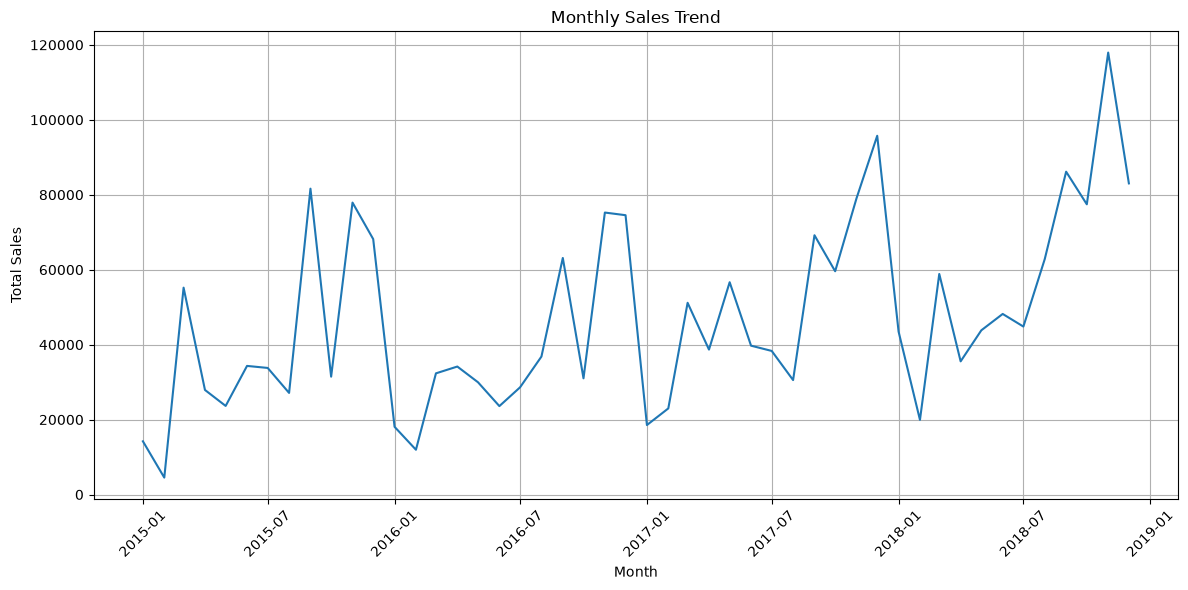

In [31]:
plt.figure(figsize=(12, 6))

plt.plot( Monthly_Sales['Year_Month'], Monthly_Sales['Sales'])
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("Visualization/monthly_sales_trend_analysis.png",dpi=300,bbox_inches="tight")
plt.show()

### Yearly Sales Analysis

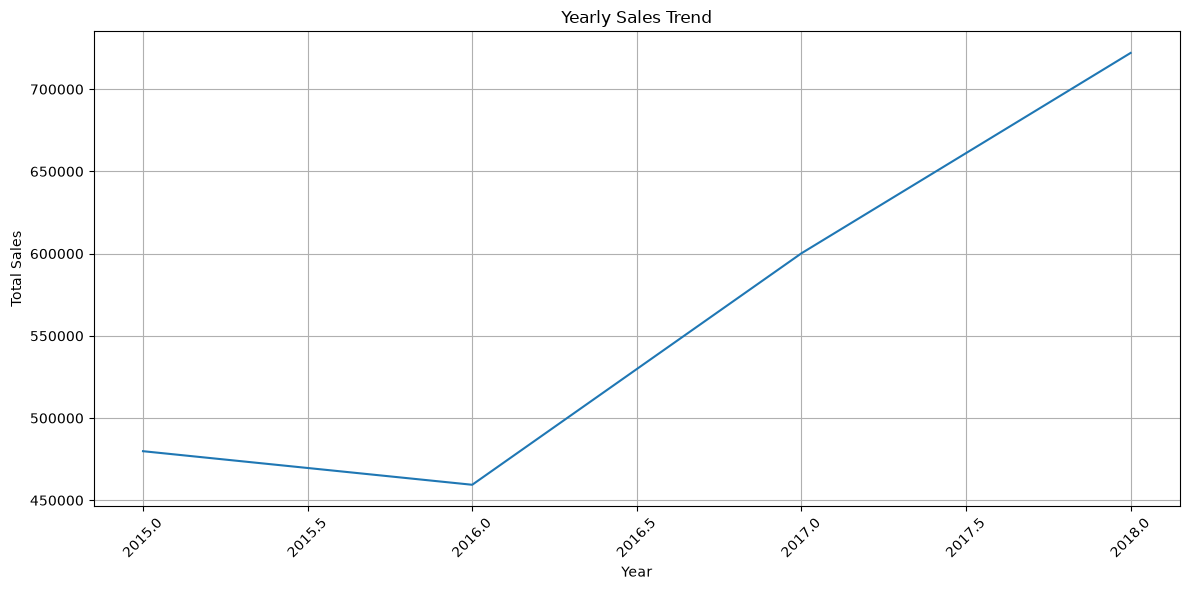

In [32]:
plt.figure(figsize=(12, 6))

plt.plot( Yearly_Sales['Order_Year'], Yearly_Sales['Sales'])
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("Visualization/yearly_sales_trend_analysis.png",dpi=300,bbox_inches="tight")
plt.show()

### Actual vs Predicted Sales Visualization

The actual and predicted sales values were compared using a line chart. The actual sales line represents the observed monthly sales, while the predicted sales line represents the values generated by the Linear Regression model. The difference between the two lines indicates the prediction error. This comparison helps evaluate how closely the model follows the actual sales trend.


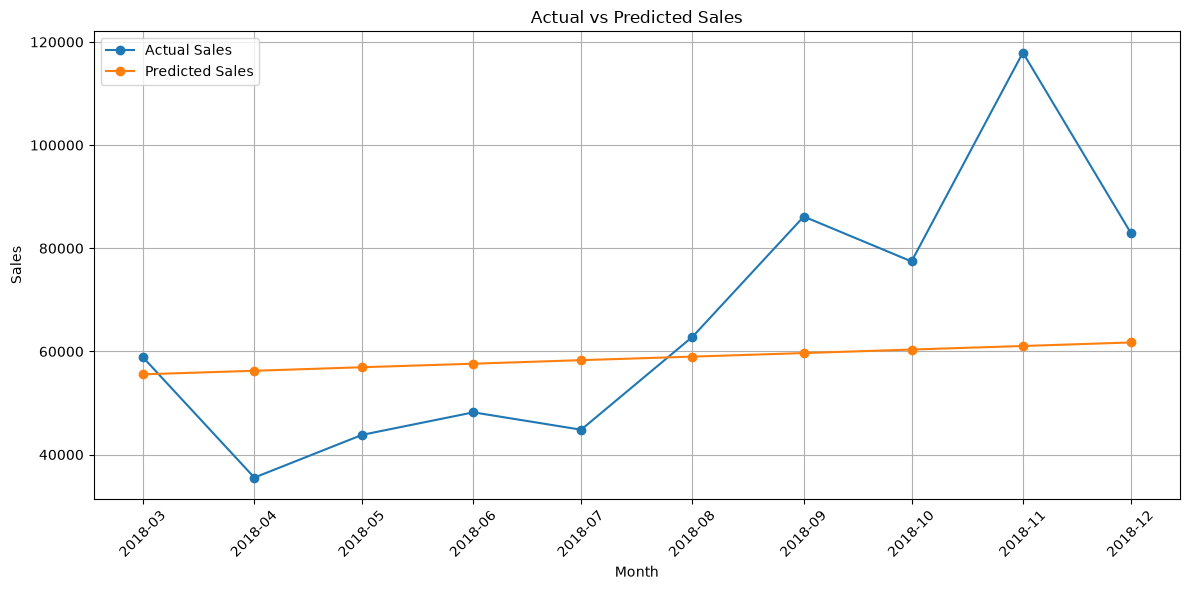

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(test['Year_Month'], test['Sales'], marker='o', label='Actual Sales')

plt.plot(test['Year_Month'], test['Predicted_Sales'], marker='o', label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("Visualization/actual_vs_predicted.png", dpi=300, bbox_inches='tight')

plt.show()

### Future Sales Forcasting

The trained Linear Regression model was used to forecast sales for the next six months. Future time indices were generated based on the historical monthly sales data, and the trained model was used to predict the corresponding sales values. The forecast provides an estimated view of the expected future sales trend and can support basic business planning and decision-making.


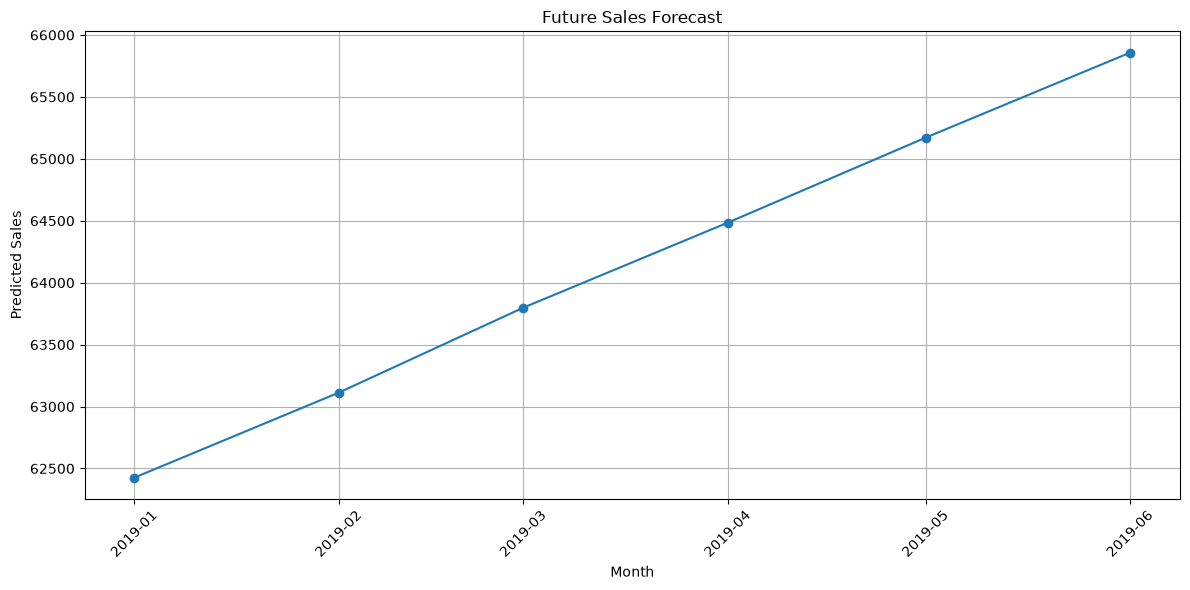

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(future_df['Year_Month'], future_df['Predicted_Sales'], marker='o')

plt.title('Future Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Predicted Sales')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("Visualization/future_sales_forcast.png", dpi=300, bbox_inches='tight')
plt.show()

## Business Insights

### Historical vs Future Sales Analysis

In [49]:
print("Historical Average Monthly Sales:")
print(Monthly_Sales['Sales'].mean())

print("\nFuture Average Forecasted Sales:")
print(future_df['Predicted_Sales'].mean())

print("\nFirst Future Month:")
print(future_df.iloc[0])

print("\nLast Future Month:")
print(future_df.iloc[-1])

Historical Average Monthly Sales:
47115.34963958333

Future Average Forecasted Sales:
64142.12033271146

First Future Month:
Time_Index                          48
Year_Month         2019-01-01 00:00:00
Predicted_Sales           62426.416513
Name: 0, dtype: object

Last Future Month:
Time_Index                          53
Year_Month         2019-06-01 00:00:00
Predicted_Sales           65857.824152
Name: 5, dtype: object


In [50]:
first_forecast = future_df['Predicted_Sales'].iloc[0]
last_forecast = future_df['Predicted_Sales'].iloc[-1]

forecast_growth = ((last_forecast - first_forecast) / first_forecast) * 100

print("Forecast Growth (%):", forecast_growth)

Forecast Growth (%): 5.4967237115282


In [51]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order_Year', 'Order_Month',
       'Order_Month_Name', 'Order_Day', 'Year_Month'],
      dtype='str')

## Save Cleaned Data

In [52]:
df.to_csv("SuperStore_Sales_Cleaned_Dataset.csv", index=False)

In [53]:
import os
print(os.path.exists("SuperStore_Sales_Cleaned_Dataset.csv"))

True
